# The Project Design

## 1. Perception Layer (Image Processing)

These components process raw user photos to detect clothing items and extract attributes. Where supported by the platform, models can run in parallel using threads.

### A. Clothing Detection & Segmentation (RF-DETR Segmentation Nano)

**Model:** RF-DETR Segmentation Nano (Instance Segmentation), trained on Fashionpedia (≈50K images with masks).
**Purpose:** Detect garments (top/bottom/shoes), crop them, and provide category + confidence.

#### Input:

A raw photo of a person or a flat-lay clothing image.

#### Output:

A list of detected clothing items (bbox + mask + category + confidence + cropped image).

#### Example:

```txt
Input:
    PIL.Image()  # e.g. (1920x1080)

Output:
    [
        {
            "category_id": 1,         # "Top"
            "confidence": 0.98,
            "bbox": [100, 50, 400, 500],
            "mask": np.ndarray(...),  # optional binary mask
            "image": PIL.Image()      # Cropped Top
        },
        {
            "category_id": 2,         # "Bottom"
            "confidence": 0.94,
            "bbox": [120, 420, 420, 980],
            "mask": np.ndarray(...),
            "image": PIL.Image()
        }
    ]
```

Local files not found. Loading from Hugging Face Hub: valentinafeve/yolos-fashionpedia


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

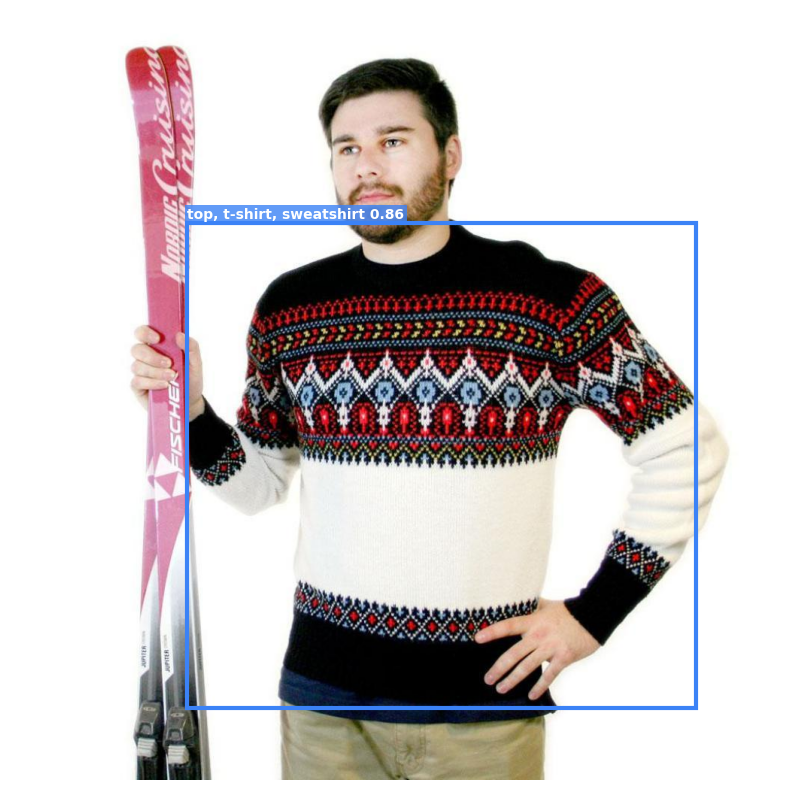

Detected 1 garments in examples/ex1.jpeg
  top, t-shirt, sweatshirt (0.86)


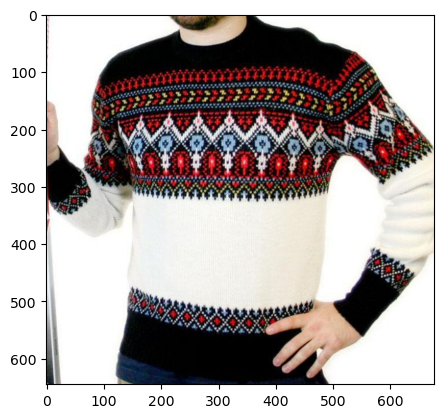

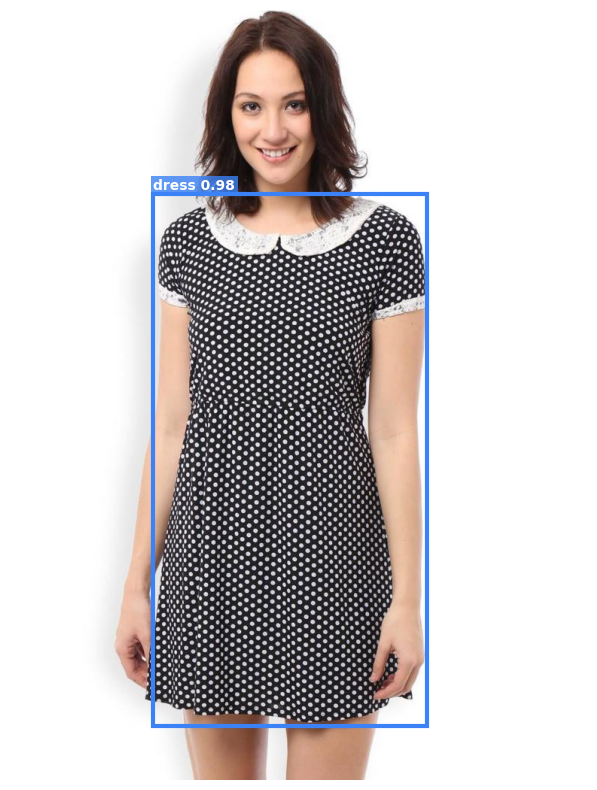

Detected 1 garments in examples/ex4.jpeg
  dress (0.98)


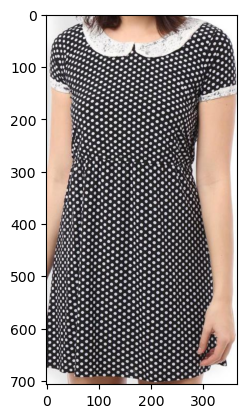

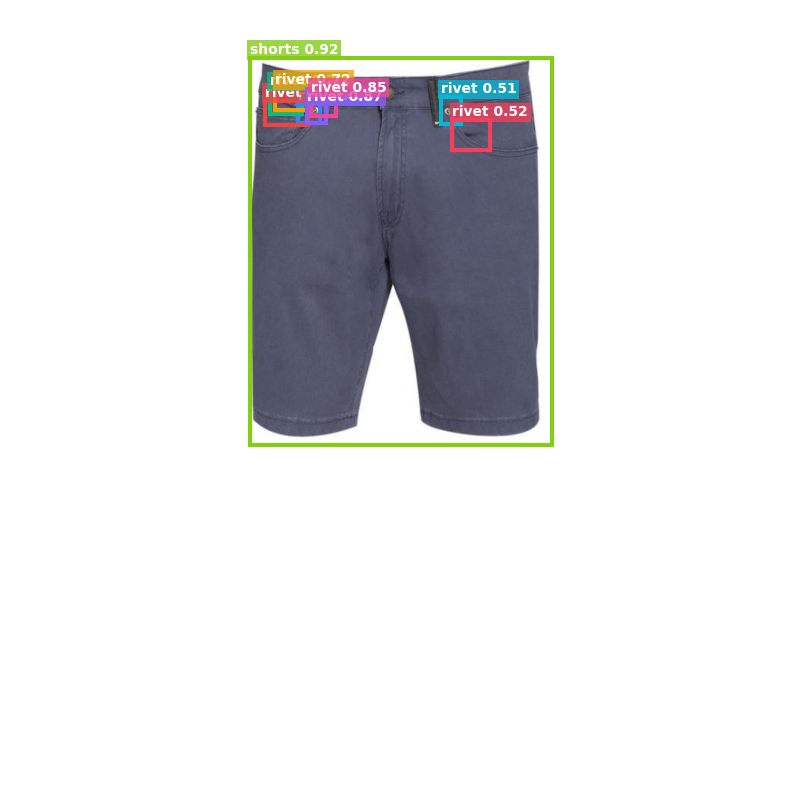

Detected 9 garments in examples/ex5.jpeg
  rivet (0.86)
  rivet (0.79)
  rivet (0.70)
  rivet (0.72)
  rivet (0.87)
  rivet (0.85)
  rivet (0.51)
  shorts (0.92)
  rivet (0.52)


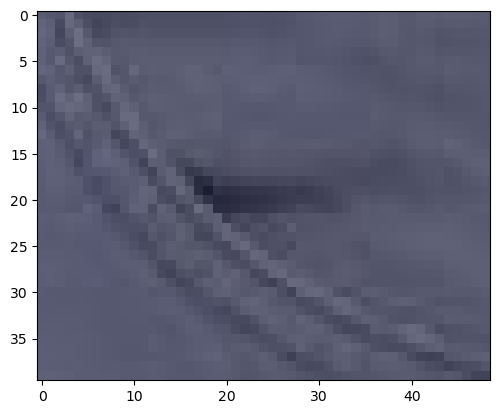

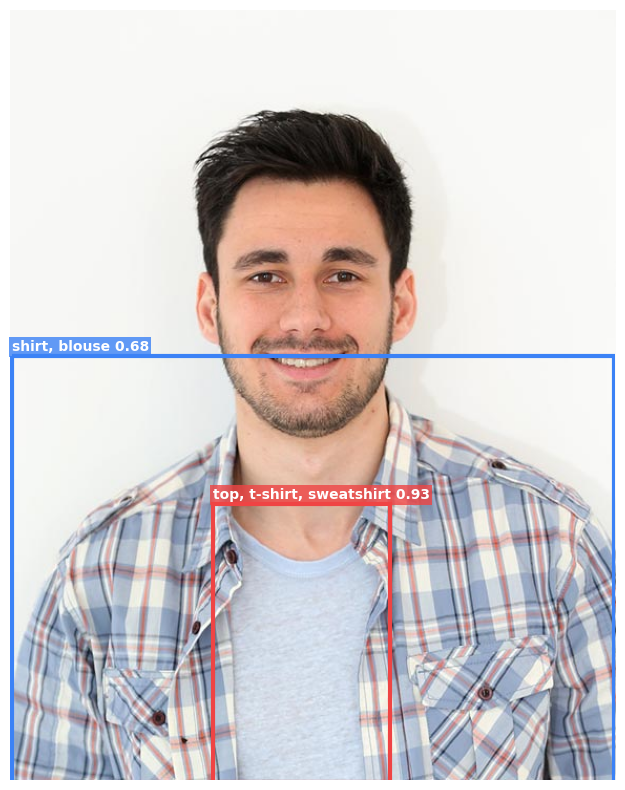

Detected 2 garments in examples/ex6.jpg
  shirt, blouse (0.68)
  top, t-shirt, sweatshirt (0.93)


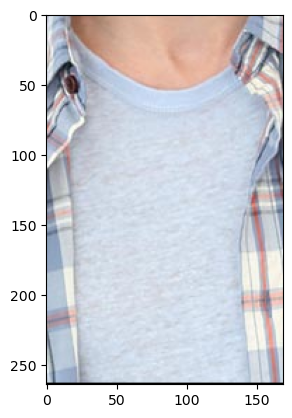

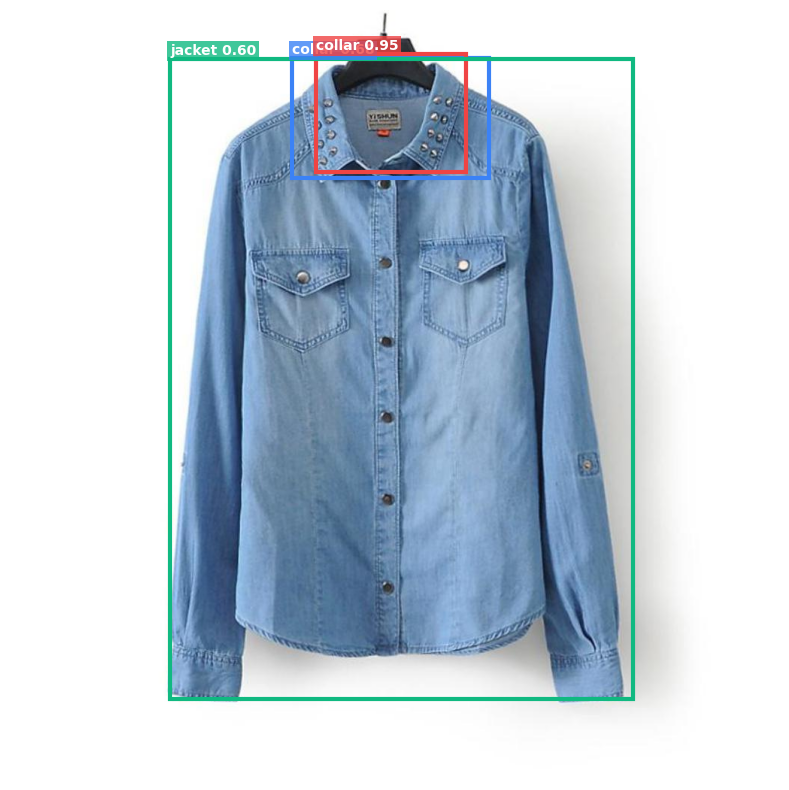

Detected 3 garments in examples/ex2.jpeg
  collar (0.68)
  collar (0.95)
  jacket (0.60)


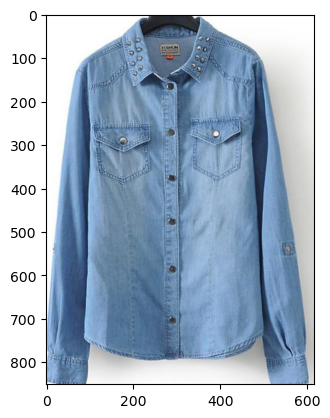

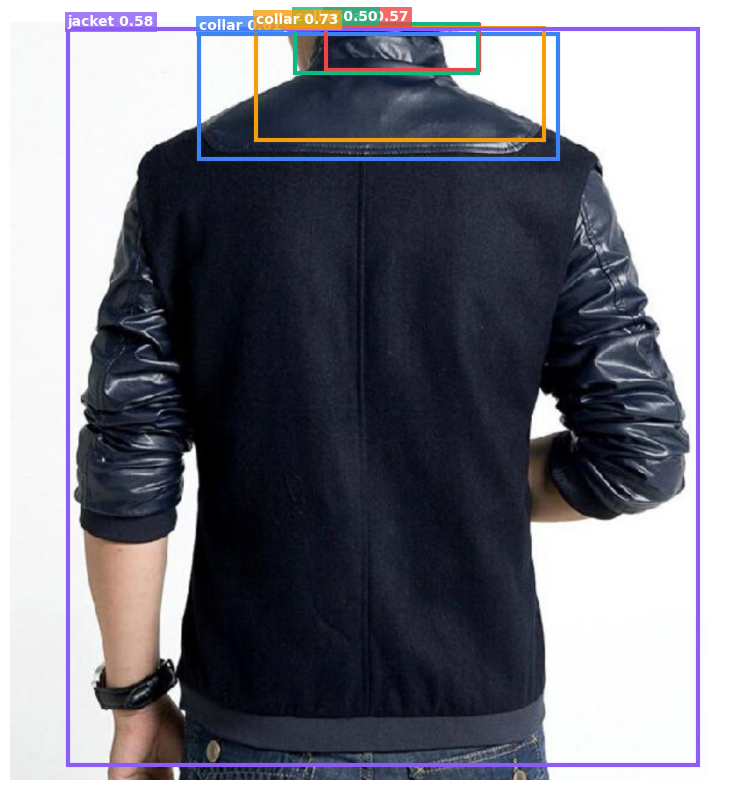

Detected 5 garments in examples/ex3.jpeg
  collar (0.61)
  collar (0.57)
  collar (0.50)
  collar (0.73)
  jacket (0.58)


{'examples/ex1.jpeg': {'garments': [{'category_id': 1,
    'category_name': 'top, t-shirt, sweatshirt',
    'confidence': 0.8617990612983704,
    'bbox': [235.43368530273438,
     282.51318359375,
     911.9573974609375,
     927.6676025390625],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=677x645>}]},
 'examples/ex4.jpeg': {'garments': [{'category_id': 10,
    'category_name': 'dress',
    'confidence': 0.9795747399330139,
    'bbox': [190.1802520751953,
     244.00680541992188,
     554.1741943359375,
     951.3348388671875],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=364x707>}]},
 'examples/ex5.jpeg': {'garments': [{'category_id': 42,
    'category_name': 'rivet',
    'confidence': 0.8648838400840759,
    'bbox': [382.2273254394531,
     123.91877746582031,
     411.8115539550781,
     149.89732360839844],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=30x26>},
   {'category_id': 42,
    'category_name': 'rivet',
 

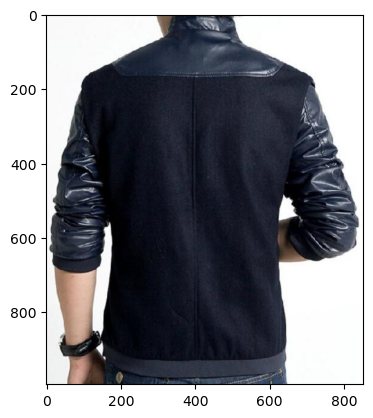

In [7]:
import os
from PIL import Image
from matplotlib import pyplot as plt

from perception_layer.clothing_detection_yolo_backup import model, inference

example_imgs = [Image.open(f"examples/{path}") for path in os.listdir("examples")]

# model_path = "perception_layer/clothing_detection_segmintation/output/checkpoint_best_regular.pth"
garment_datector = inference.GarmentDetector()
outfits = {}

for img in example_imgs:
    garments = garment_datector.predict(img, threshold=0.50)
    inference.plot_wardrobe_detections(img, garments)
    print(f"Detected {len(garments)} garments in {img.filename}")
    for garment in garments:
        print(f"  {garment['category_name']} ({garment['confidence']:.2f})")
        plt.imshow(garment["image"])
    outfits[img.filename] = {"garments":garments}

outfits


In [8]:
outfits[example_imgs[0].filename]["garments"]

[{'category_id': 1,
  'category_name': 'top, t-shirt, sweatshirt',
  'confidence': 0.8617990612983704,
  'bbox': [235.43368530273438,
   282.51318359375,
   911.9573974609375,
   927.6676025390625],
  'mask': None,
  'image': <PIL.Image.Image image mode=RGB size=677x645>}]

In [6]:
example_imgs[5].filename

'examples/ex3.jpeg'

### B. Multi-Attribute Classifier (EfficientNet-B0, Multi-Head)

**Architecture:** Single backbone + multiple heads.
**Why:** Run one forward pass and predict multiple attributes (saves compute vs separate models).

**Predicted attributes (examples):**

* fit: slim / regular / oversized
* style: formal / casual / sporty
* weather_warmth: 0–1 (cold → warm)
* formality_score: 0–1

#### Input:

A normalized cropped item image, optionally with the garment type id.

#### Output:

Attribute probabilities + scalar metrics.

#### Example:

```txt
Input:
    torch.Tensor()  # Shape: (1, 3, 224, 224)

Output:
    {
        "fit": torch.Tensor([0.1, 0.8, 0.1]),            # -> "Regular"
        "style": torch.Tensor([0.05, 0.9, 0.05]),        # -> "Casual"
        "weather_warmth": 0.75,                          # 0.0 cold -> 1.0 warm
        "formality_score": 0.20                          # 0.0 PJs  -> 1.0 tux
    }
```
**Labeling strategy:**

* Cloud training can use **pseudo-labeling** via a vision-language model (CLIP-style) + a small manually verified set.

---

In [9]:
from perception_layer.multi_attribute_classifire import inference
model_path = "perception_layer/multi_attribute_classifire/runs2/1b/best_model.pt"
multi_attribute_classifier = inference.AttributePredictor(model_path)
for img in example_imgs:
    for idx, garment in enumerate(outfits[img.filename]["garments"]):
        img_att = multi_attribute_classifier.predict(garment["image"].convert("RGB"))
        outfits[img.filename]["garments"][idx]["attributes"] = img_att
    print(outfits[img.filename])

{'garments': [{'category_id': 1, 'category_name': 'top, t-shirt, sweatshirt', 'confidence': 0.8617990612983704, 'bbox': [235.43368530273438, 282.51318359375, 911.9573974609375, 927.6676025390625], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=677x645 at 0x17FEDE960>, 'attributes': {'fit': [0.33680489659309387, 0.3370394706726074, 0.32615554332733154], 'style': [0.25029289722442627, 0.2491447776556015, 0.24937209486961365, 0.2511901557445526], 'weather_warmth': 0.5146522521972656, 'formality_score': 0.4979945719242096, 'fit_label': 'regular', 'style_label': 'streetwear'}}]}
{'garments': [{'category_id': 10, 'category_name': 'dress', 'confidence': 0.9795747399330139, 'bbox': [190.1802520751953, 244.00680541992188, 554.1741943359375, 951.3348388671875], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=364x707 at 0x17FC1BFB0>, 'attributes': {'fit': [0.3355661928653717, 0.3362371027469635, 0.3281966745853424], 'style': [0.25064536929130554, 0.24976541101932526, 0.24

In [10]:
outfits

{'examples/ex1.jpeg': {'garments': [{'category_id': 1,
    'category_name': 'top, t-shirt, sweatshirt',
    'confidence': 0.8617990612983704,
    'bbox': [235.43368530273438,
     282.51318359375,
     911.9573974609375,
     927.6676025390625],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=677x645>,
    'attributes': {'fit': [0.33680489659309387,
      0.3370394706726074,
      0.32615554332733154],
     'style': [0.25029289722442627,
      0.2491447776556015,
      0.24937209486961365,
      0.2511901557445526],
     'weather_warmth': 0.5146522521972656,
     'formality_score': 0.4979945719242096,
     'fit_label': 'regular',
     'style_label': 'streetwear'}}]},
 'examples/ex4.jpeg': {'garments': [{'category_id': 10,
    'category_name': 'dress',
    'confidence': 0.9795747399330139,
    'bbox': [190.1802520751953,
     244.00680541992188,
     554.1741943359375,
     951.3348388671875],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=364x70

In [12]:
outfits[example_imgs[0].filename]["garments"]

[{'category_id': 1,
  'category_name': 'top, t-shirt, sweatshirt',
  'confidence': 0.8617990612983704,
  'bbox': [235.43368530273438,
   282.51318359375,
   911.9573974609375,
   927.6676025390625],
  'mask': None,
  'image': <PIL.Image.Image image mode=RGB size=677x645>,
  'attributes': {'fit': [0.33680489659309387,
    0.3370394706726074,
    0.32615554332733154],
   'style': [0.25029289722442627,
    0.2491447776556015,
    0.24937209486961365,
    0.2511901557445526],
   'weather_warmth': 0.5146522521972656,
   'formality_score': 0.4979945719242096,
   'fit_label': 'regular',
   'style_label': 'streetwear'}}]

### E. Color Harmony Score (Function)

#### Input:

Cropped clothing item images and the number of dominant colors per garment.

#### Output:

Color harmony score between 0 and 1 of the cropped images combined

#### Example:
```txt
Input:
    images : list[PIL.Image, PIL.Image, PIL.Image] # 3 images
    k : 5 # number of dominant colors per garment

Output:
    0.75 #  The color harmony score is 75%
```

In [ ]:
from perception_layer import color_utils
for img in example_imgs:
    outfit_cropped_imgs = [garment["image"].convert("RGB") for garment in outfits[img.filename]["garments"]]
    outfits[img.filename]["color_harmony"] = color_utils.harmony_score_from_images(outfit_cropped_imgs)
    print(outfits[img.filename])

## 2. Textual Query Understanding (Semantic Processing)

This layer transforms a user request (text) into intent signals and an embedding usable by ranking.

### A. Query Vectorization (Mobile Text Encoder)

**Model:** Distilled BERT / MobileCLIP text branch.
**Purpose:** Encode user query into a 512-dim vector aligned with image vectors.

#### Input:

A user query string.

#### Output:

A 512-dim embedding vector.

#### Example:

```txt
Input:
    "business meeting, looking for comfort"

Output:
    torch.Tensor()  # Shape: (1, 512)
```

In [14]:
from semantic_processing.ranking_utils import garment_score
from semantic_processing.query_vectorization.query_vectorizer import QueryVectorizer

usr_input_sentence = "I have a business meeting, looking for comfort"
sentence_transformer = QueryVectorizer(model_path="semantic_processing/query_vectorization/distilled_query_encoder.pth")
query_vec = sentence_transformer.encode(usr_input_sentence)

filters = {
    "min_formality": 0.4,
    "max_warmth": 0.7,
    "sporty_ok": False
}

context = {
    "temperature": 20
}
for filename, data in outfits.items():
    for garment in data["garments"]:
        score = garment_score(
            garment,
            query_vec,
            filters,
            context
        )

        garment["match_score"] = round(score, 3)

    print(filename, data["garments"])

examples/ex1.jpeg [{'category_id': 1, 'category_name': 'top, t-shirt, sweatshirt', 'confidence': 0.8617990612983704, 'bbox': [235.43368530273438, 282.51318359375, 911.9573974609375, 927.6676025390625], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=677x645 at 0x17FEDE960>, 'attributes': {'fit': [0.33680489659309387, 0.3370394706726074, 0.32615554332733154], 'style': [0.25029289722442627, 0.2491447776556015, 0.24937209486961365, 0.2511901557445526], 'weather_warmth': 0.5146522521972656, 'formality_score': 0.4979945719242096, 'fit_label': 'regular', 'style_label': 'streetwear'}, 'match_score': 0.798}]
examples/ex4.jpeg [{'category_id': 10, 'category_name': 'dress', 'confidence': 0.9795747399330139, 'bbox': [190.1802520751953, 244.00680541992188, 554.1741943359375, 951.3348388671875], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=364x707 at 0x17FC1BFB0>, 'attributes': {'fit': [0.3355661928653717, 0.3362371027469635, 0.3281966745853424], 'style': [0.2506453692913

## 3. Representation Layer (Vectorization)

This layer produces vectors for fast similarity search and outfit relevance.

### A. Visual Embeddings (Student CLIP)

**Model:** MobileNetV3 image encoder distilled from CLIP (ViT teacher).
**Purpose:** Convert each item image into a normalized 512-dim “vibe” embedding.

#### Input:

Cropped image tensor.

#### Output:

Normalized embedding.

#### Example:

```txt
Input:
    torch.Tensor()  # (1, 3, 224, 224)

Output:
    torch.Tensor()  # (1, 512)
```

---

### B. Text Embeddings

**Purpose:** Ensure text and image vectors live in the same embedding space (512-dim).

---

### C. Local Vector Store

**Storage:** SQLite + local files, or a compact ANN index.
**Purpose:** Nearest-neighbor retrieval without internet.

#### Example:

```txt
Stored:
    item_id -> embedding(512) + metadata
Search:
    top_k by cosine similarity
```

---